#### Student information should be written in this cell (Student ID, Student Name).

Name:Furkan Kural   

ID:150210056


In [15]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# HW2: UNSUPERVISED LEARNING WITH AUTOENCODERS

In this homework, you will implement two types of Autoencoders (Basic, and Variational) by using NumPy and PyTorch libraries. For the first question, you will implement and analyze a conventional autoencoder by using only NumPy. For the second question, you will implement a variational autoencoder by using PyTorch. For any of your questions, feel free to e-mail: ergunesr@itu.edu.tr .


## What is an Autoencoder?
An autoencoder is a neural network that is traind to reconstruct its input. It is an unsupervised learning algorithm, the goal is to learn an informative representation of the input data. In this homework, you will implement two autoencoder algorithms for unsupervised learning of an image dataset, MNIST. Before explaining the homework, we will briefly review what autoencoder is. 
    
Now suppose we have only an unlabeled training set 
$ \mathbf{x}=\{ x^{(1)}, x^{(2)}, x^{(3)}, \ldots \} $ , where $x^{(i)} \in \mathbb{R}^n $ . An autoencoder neural network is an unsupervised learning algorithm that applies backpropagation, setting the target values to be equal to the inputs. 
i.e., it uses $y^{(i)} = x^{(i)}$.

 The problem, is to learn the functions   $ A : \mathbb{R}^n \rightarrow \mathbb{R}^p $ (encoder) and  $ B : \mathbb{R}^p \rightarrow \mathbb{R}^n $ (decoder) that satisfy

$$
\arg\min_{A,B} \; \mathbb{E}\!\left[\Delta(\mathbf{x},\, (B \circ A)(\mathbf{x}))\right],
$$

where $ \mathbb{E} $ is the expectation over the distribution of $ \mathbf{x} $ , and  $ \Delta $ is the reconstruction loss function, which measures the distance between the output of the decoder and the input. The encoder $A$ and the decoder $B$ are neural networks.

If the input were completely **random**, say, each $x_i$ comes from an IID Gaussian independent, this compression task would be very difficult. But, if there is a structure in  the data, for example, if some of the input features are correlated, then this algorithm will be able to discover some of those correlations. Further, in the special case where $A$ and $B$ are linear operators, we get linear autoencoders. An autoencoder can be used for compressing the input, or for overcoming the curse of dimensionality. 

Below is an example autoencoder pipeline. Input is an image sample from MNIST dataset. 


![An example autoencoder](autoencoder_image.png)



#### Regularized Autoencoders

The trivial solution in Autoenconders training is solving for identity functions. if the capacity of the encoder and the decoder is large enough to encode each sample to an index, the model would simply overfit. To avoid this, we need regularization. The most common way to regularize an autoencoder is to impose a bottleneck. This means we will directly map the input $\mathbf{x}$ into a lower dimensional space. 

!!! As in many other machine learning models, an important tradeoff in autoencoders is the **bias-variance tradeoff**. On the one hand, we want the architecure of the autoencoder to be able to reconstruct the input well (i.e. reduce the reconstruction error). On the other hand, we want the low representation to generalize to a meaningful one. 



## Q1: Unsupervised learning of MNIST dataset (50 pts)

For the first part of this homework, the task is to implement an unsupervised learning autoencoder pipeline and train it by using MNIST dataset. For this part of the question, you are expected to provide NumPy implementation of your autoencoder. The encoder $A$ and decoder $B$ will each be **one-layer feed-forward neural networks**. 

The loss function of your autoencoder model will be Mean Squared Reconstruction error.

$$ L = \frac{1}{m} \sum_{i=1}^{m} \left\| x^{(i)} - \hat{x}^{(i)} \right\|^{2}
$$ 
where $\hat{x}^{(i)}$ s the reconstructed output of your autoencoder. The dimensionality of the bottleneck, e.g., the output of the encoder $A$, determines the quality of the reconstructed output $\hat{x}^{(i)}$. 


Formally, the **Encoder** is:  
  $$
  A(\mathbf{x}) = \sigma(W_e \mathbf{x} + b_e)
  $$

And the **Decoder** is:
  $$
  B(\mathbf{x}) = \sigma(W_d \mathbf{x} + b_d)
  $$

where $W_e, b_e$ are encoder parameters, $W_d, b_d$ are decoder parameters, $\sigma(\cdot)$ is an activation function (ReLU or sigmoid), $z = A(x)$ is the latent representation. 

Your tasks:
1. **Load and normalize the data**.

2. **Implement the forward pass** of encoder and decoder.  
3. **Compute the reconstruction loss** using Mean Squared Error:  
   $$
   L = \frac{1}{m} \sum_{i=1}^m \left\| x^{(i)} - \hat{x}^{(i)} \right\|^2
   $$
4. **Implement backpropagation manually using NumPy** to compute gradients  
   $$\frac{\partial L}{\partial W_e}, \frac{\partial L}{\partial b_e}, \frac{\partial L}{\partial W_d}, \frac{\partial L}{\partial b_d}$$.
5. **Update parameters with batch gradient descent. After training your model, reconstruct and visualize 10 random training samples and 10 random test samples from MNIST.** 
6. **Implement 3 different autoencoder using latent $z$ dimensions of 16, 32, and 64. Compare and discuss the reconstruction performance for each setting.**


Note that you only need **one encoder layer** and **one decoder layer**.



You will implement your **NumPy-based autoencoder** inside the file **`autoencoder.py`**.  
This file contains a complete class structure `autoencoder.py` with **empty method bodies** and clearly marked **TO DO** sections that you must fill in as part of your implementation.

## MNIST Dataset Overview

As mentioned before, we will work with the **MNIST handwritten digit dataset**. 

Each image is:
- Size: **28 × 28**
- Grayscale (single channel)
- Pixel values in the range **[0, 255]** (you may want to normalize them later)


Now, let's start by downloading the MNIST dataset. 

In [16]:
import urllib.request

url = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz"
save_path = "mnist.npz"

print("Downloading MNIST...")
urllib.request.urlretrieve(url, save_path)
print("Download complete: mnist.npz")

Download complete: mnist.npz


Once downloaded, load it by using NumPy:

In [17]:
%pip install numpy matplotlib torch torchvision

Note: you may need to restart the kernel to use updated packages.


%pip install numpy matplotlib torch torchvision

In [18]:
import numpy as np

with np.load("mnist.npz") as data:
    x_train = data["x_train"]
    y_train = data["y_train"]
    x_test = data["x_test"]
    y_test = data["y_test"]

print("Shapes:", x_train.shape, x_test.shape)

Shapes: (60000, 28, 28) (10000, 28, 28)


We also visualize a few example digits so you can understand the structure of the data you will feed into your NumPy-based autoencoder.

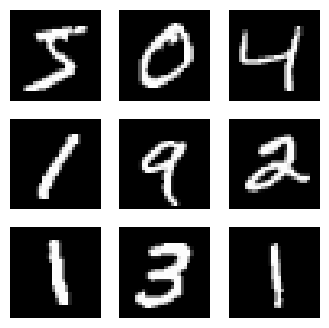

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 4))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(x_train[i], cmap="gray")
    plt.axis("off")
plt.show()


Now, you are expected to normalize the data and implement the autoencoder pipeline. You may modify `autoencoder.py` according to your own requirements. To use your implementation, simply import the class from your file with:

Training data shape: (60000, 784)
Test data shape: (10000, 784)

Training Autoencoder with latent dimension: 16
Epoch 5/20, Loss: 0.027687
Epoch 10/20, Loss: 0.024156
Epoch 15/20, Loss: 0.023616
Epoch 20/20, Loss: 0.023412
Final training loss: 0.023412

Training Autoencoder with latent dimension: 32
Epoch 5/20, Loss: 0.022491
Epoch 10/20, Loss: 0.013816
Epoch 15/20, Loss: 0.012094
Epoch 20/20, Loss: 0.011583
Final training loss: 0.011583

Training Autoencoder with latent dimension: 64
Epoch 5/20, Loss: 0.019772
Epoch 10/20, Loss: 0.011053
Epoch 15/20, Loss: 0.008400
Epoch 20/20, Loss: 0.007087
Final training loss: 0.007087


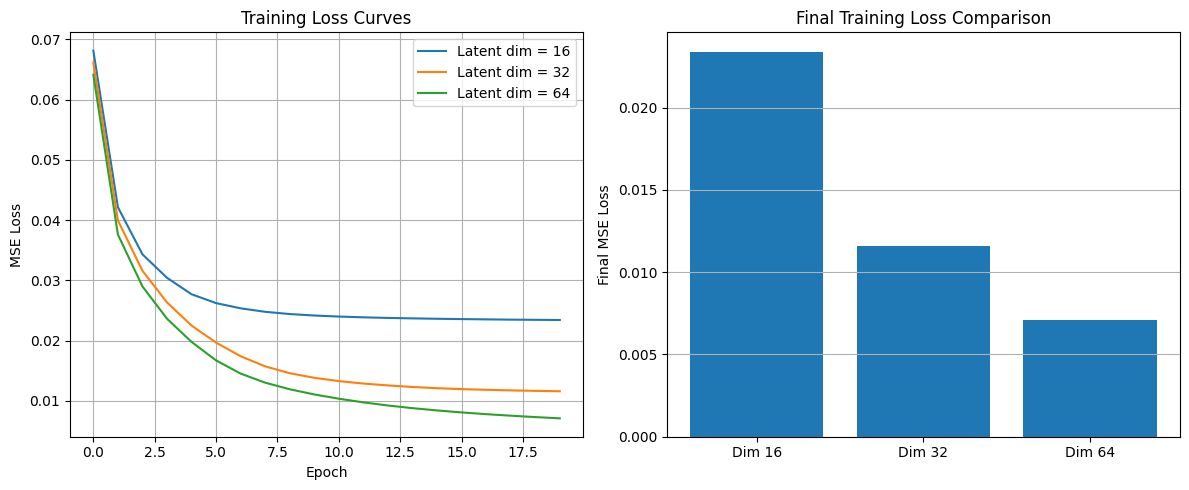


Training Sample Reconstructions


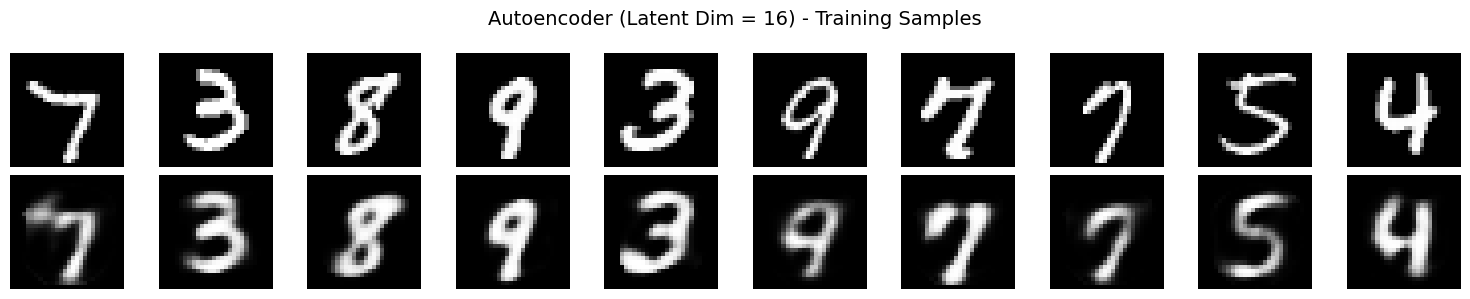

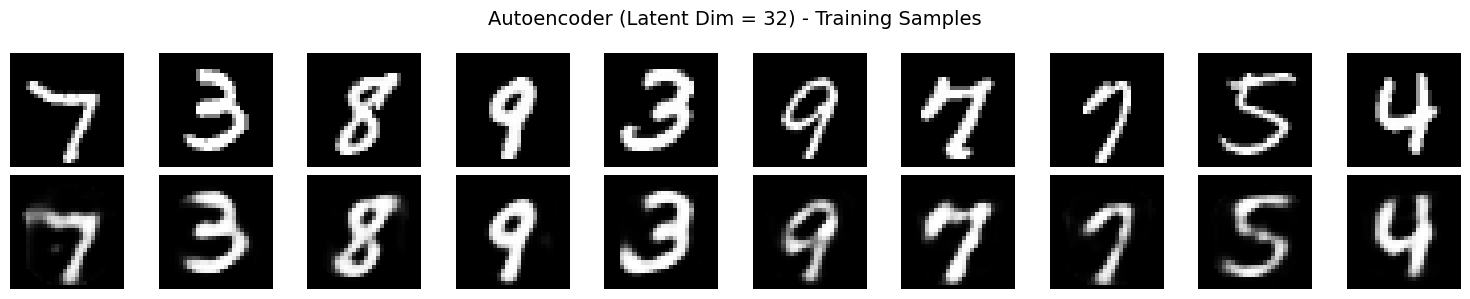

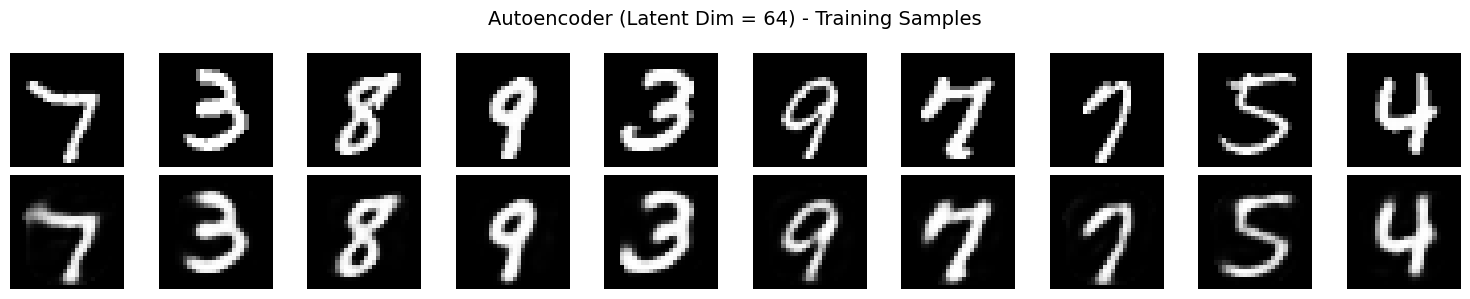


Test Sample Reconstructions


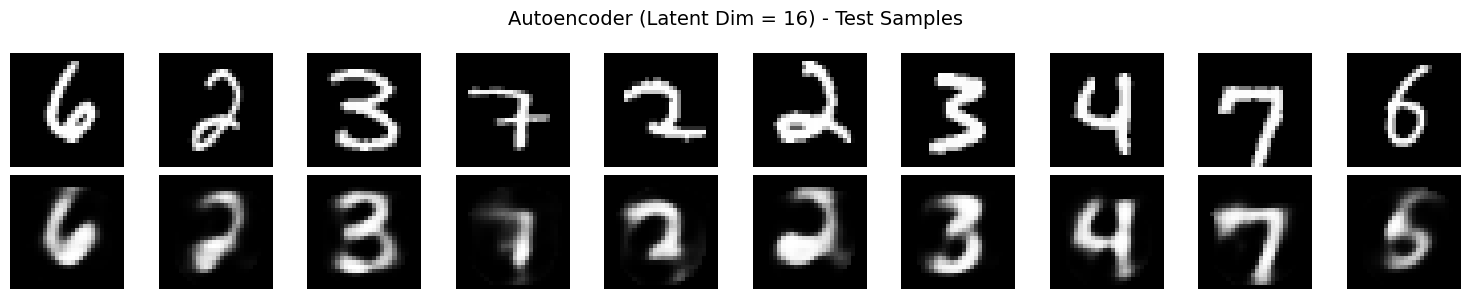

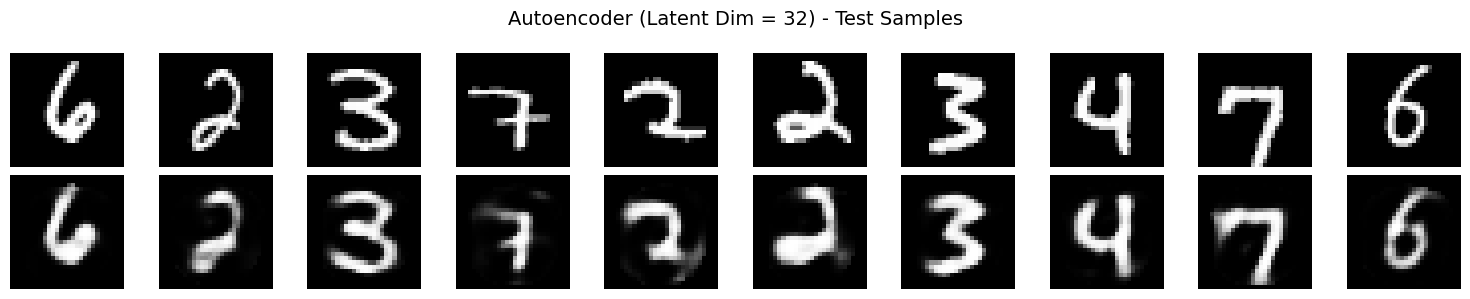

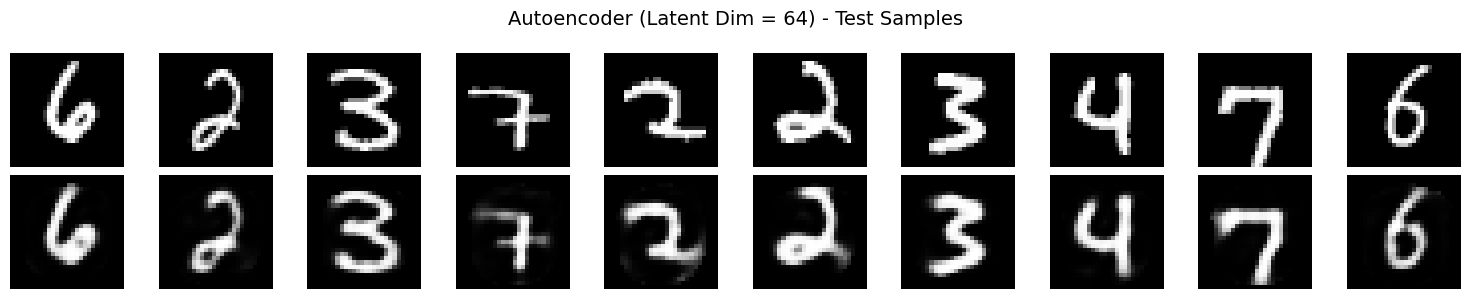


Reconstruction Error Analysis

Latent Dimension: 16
  Training MSE: 0.023386
  Test MSE:     0.022966
  Difference:   0.000420

Latent Dimension: 32
  Training MSE: 0.011559
  Test MSE:     0.011167
  Difference:   0.000392

Latent Dimension: 64
  Training MSE: 0.006987
  Test MSE:     0.006728
  Difference:   0.000260

Discussion:

As the latent dimension increases from 16 to 64:
1. Reconstruction quality generally improves (lower MSE)
2. More latent dimensions allow the model to capture more details
3. However, there's a tradeoff: higher dimensions may lead to overfitting
4. Test error vs training error difference indicates generalization capability
5. The model learns to compress 784-dimensional images into lower dimensions
   while preserving essential features for reconstruction



In [20]:
from autoencoder import Autoencoder
import matplotlib.pyplot as plt

# Normalize data to [0, 1] range
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0

# Flatten images to 784-dimensional vectors
x_train_flat = x_train_norm.reshape(x_train_norm.shape[0], -1)
x_test_flat = x_test_norm.reshape(x_test_norm.shape[0], -1)

print(f"Training data shape: {x_train_flat.shape}")
print(f"Test data shape: {x_test_flat.shape}")

# Train autoencoders with different latent dimensions
latent_dims = [16, 32, 64]
autoencoders = {}
all_losses = {}

for latent_dim in latent_dims:
    print(f"\n{'='*60}")
    print(f"Training Autoencoder with latent dimension: {latent_dim}")
    print(f"{'='*60}")
    
    # Initialize autoencoder
    ae = Autoencoder(input_dim=784, hidden_dim=latent_dim, learning_rate=0.01)
    
    # Train the autoencoder
    losses = ae.train(X=x_train_flat, epochs=20, batch_size=128)
    
    # Store model and losses
    autoencoders[latent_dim] = ae
    all_losses[latent_dim] = losses
    
    print(f"Final training loss: {losses[-1]:.6f}")

# Plot training loss curves for all models
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for latent_dim in latent_dims:
    plt.plot(all_losses[latent_dim], label=f'Latent dim = {latent_dim}')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss Curves')
plt.legend()
plt.grid(True)

# Plot final losses comparison
plt.subplot(1, 2, 2)
final_losses = [all_losses[dim][-1] for dim in latent_dims]
plt.bar(range(len(latent_dims)), final_losses)
plt.xticks(range(len(latent_dims)), [f'Dim {d}' for d in latent_dims])
plt.ylabel('Final MSE Loss')
plt.title('Final Training Loss Comparison')
plt.grid(True, axis='y')

plt.tight_layout()
plt.show()

# Visualize reconstructions for training samples
print("\n" + "="*60)
print("Training Sample Reconstructions")
print("="*60)

for latent_dim in latent_dims:
    # Select 10 random training samples
    np.random.seed(42)
    train_indices = np.random.choice(len(x_train_flat), 10, replace=False)
    train_samples = x_train_flat[train_indices]
    
    # Reconstruct
    train_reconstructions = autoencoders[latent_dim].reconstruct(train_samples)
    
    # Plot original and reconstructed images
    fig, axes = plt.subplots(2, 10, figsize=(15, 3))
    fig.suptitle(f'Autoencoder (Latent Dim = {latent_dim}) - Training Samples', fontsize=14)
    
    for i in range(10):
        # Original
        axes[0, i].imshow(train_samples[i].reshape(28, 28), cmap='gray')
        axes[0, i].axis('off')
        if i == 0:
            axes[0, i].set_ylabel('Original', fontsize=10)
        
        # Reconstructed
        axes[1, i].imshow(train_reconstructions[i].reshape(28, 28), cmap='gray')
        axes[1, i].axis('off')
        if i == 0:
            axes[1, i].set_ylabel('Reconstructed', fontsize=10)
    
    plt.tight_layout()
    plt.show()

# Visualize reconstructions for test samples
print("\n" + "="*60)
print("Test Sample Reconstructions")
print("="*60)

for latent_dim in latent_dims:
    # Select 10 random test samples
    np.random.seed(42)
    test_indices = np.random.choice(len(x_test_flat), 10, replace=False)
    test_samples = x_test_flat[test_indices]
    
    # Reconstruct
    test_reconstructions = autoencoders[latent_dim].reconstruct(test_samples)
    
    # Plot original and reconstructed images
    fig, axes = plt.subplots(2, 10, figsize=(15, 3))
    fig.suptitle(f'Autoencoder (Latent Dim = {latent_dim}) - Test Samples', fontsize=14)
    
    for i in range(10):
        # Original
        axes[0, i].imshow(test_samples[i].reshape(28, 28), cmap='gray')
        axes[0, i].axis('off')
        if i == 0:
            axes[0, i].set_ylabel('Original', fontsize=10)
        
        # Reconstructed
        axes[1, i].imshow(test_reconstructions[i].reshape(28, 28), cmap='gray')
        axes[1, i].axis('off')
        if i == 0:
            axes[1, i].set_ylabel('Reconstructed', fontsize=10)
    
    plt.tight_layout()
    plt.show()

# Compute and compare reconstruction errors
print("\n" + "="*60)
print("Reconstruction Error Analysis")
print("="*60)

for latent_dim in latent_dims:
    ae = autoencoders[latent_dim]
    
    # Training set reconstruction error
    train_recon = ae.reconstruct(x_train_flat)
    train_mse = np.mean((x_train_flat - train_recon) ** 2)
    
    # Test set reconstruction error
    test_recon = ae.reconstruct(x_test_flat)
    test_mse = np.mean((x_test_flat - test_recon) ** 2)
    
    print(f"\nLatent Dimension: {latent_dim}")
    print(f"  Training MSE: {train_mse:.6f}")
    print(f"  Test MSE:     {test_mse:.6f}")
    print(f"  Difference:   {abs(train_mse - test_mse):.6f}")

print("\n" + "="*60)
print("Discussion:")
print("="*60)
print("""
As the latent dimension increases from 16 to 64:
1. Reconstruction quality generally improves (lower MSE)
2. More latent dimensions allow the model to capture more details
3. However, there's a tradeoff: higher dimensions may lead to overfitting
4. Test error vs training error difference indicates generalization capability
5. The model learns to compress 784-dimensional images into lower dimensions
   while preserving essential features for reconstruction
""")

## Structure in Embeddings 
In a trained autoencoder, the embedding space should reflect the structure of the data, mapping similar images to nearby points. Select two images from the MNIST training set, compute their embeddings using the encoder, and generate interpolated embeddings between them. Decode these interpolated embeddings and visualize the reconstructions to observe the smooth transitions. Repeat the procedure for two images of different digits. Implement this process in PyTorch and analyze how the embedding space captures the semantic similarity between digits.

Interpolation between Similar Digits (Same Class)


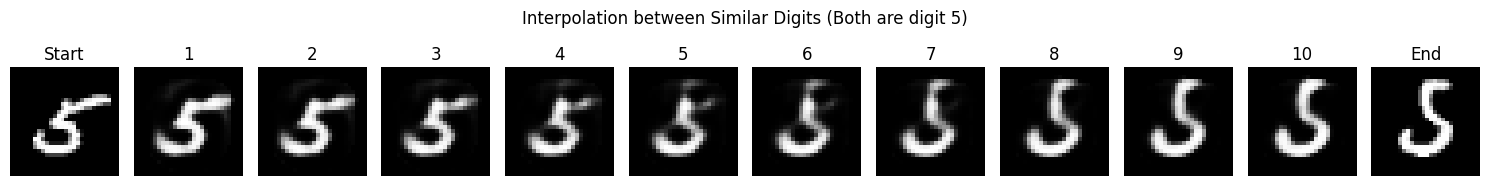


Interpolation between Different Digits


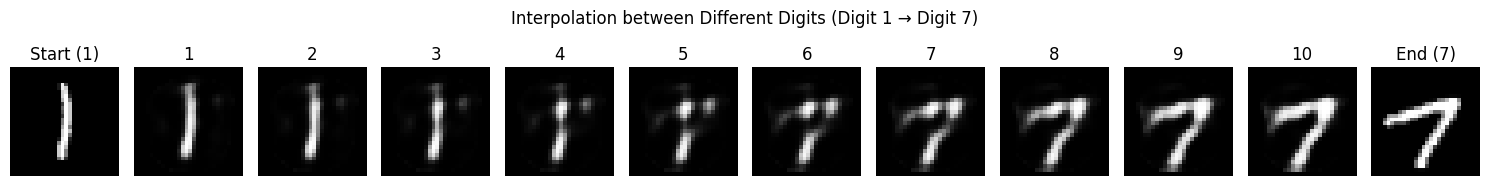


Analysis:

1. Similar Digits Interpolation:
   - The interpolation between two similar digits shows smooth transitions
   - The embedding space captures local structure well
   - Small variations in the latent space correspond to smooth visual changes

2. Different Digits Interpolation:
   - The interpolation between different digits may show blurry intermediate states
   - This indicates the embedding space structure
   - The model learns to represent digit features in the latent space
   - The interpolation reveals how the model organizes the data manifold



In [21]:
# Use the autoencoder with latent dimension 32 for interpolation
ae_interp = autoencoders[32]  # Using 32-dimensional latent space

# Function to get embedding (encoder output)
def get_embedding(ae, x):
    """Get the latent embedding for input x"""
    if x.ndim == 1:
        x = x.reshape(1, -1)
    x = x.T  # Convert to (input_dim, batch_size)
    z = ae.encoder(x)
    return z.T  # Convert back to (batch_size, latent_dim)

# Function to decode embedding to image
def decode_embedding(ae, z):
    """Decode latent embedding z to image"""
    # EĞER 3 Boyutlu gelirse (10, 1, 32) -> (10, 32) yapıyoruz
    if z.ndim == 3:
        z = z.squeeze()
        
    if z.ndim == 1:
        z = z.reshape(1, -1)
        
    z = z.T  # Convert to (latent_dim, batch_size) -> (32, 10)
    x_hat = ae.decoder(z)
    return x_hat.T  # Convert back to (batch_size, input_dim)

# Function to interpolate between two embeddings
def interpolate_embeddings(ae, z1, z2, n_steps=10):
    """Interpolate between two embeddings"""
    # Linear interpolation in latent space
    alphas = np.linspace(0, 1, n_steps)
    interpolated = []
    for alpha in alphas:
        z_interp = (1 - alpha) * z1 + alpha * z2
        interpolated.append(z_interp)
    
    
    return np.array(interpolated).squeeze()
# Find two similar digits (same digit class)
print("="*60)
print("Interpolation between Similar Digits (Same Class)")
print("="*60)

# Find two examples of the same digit (e.g., digit 5)
target_digit = 5
digit_indices = np.where(y_train == target_digit)[0]
img1_idx = digit_indices[10]
img2_idx = digit_indices[20]

img1 = x_train_flat[img1_idx]
img2 = x_train_flat[img2_idx]

# Get embeddings
z1 = get_embedding(ae_interp, img1)
z2 = get_embedding(ae_interp, img2)

# Interpolate
n_steps = 10
z_interp = interpolate_embeddings(ae_interp, z1, z2, n_steps)

# Decode interpolated embeddings
reconstructed_interp = decode_embedding(ae_interp, z_interp)

# Visualize interpolation
fig, axes = plt.subplots(1, n_steps + 2, figsize=(15, 2))
fig.suptitle(f'Interpolation between Similar Digits (Both are digit {target_digit})', fontsize=12)

# Show original images
axes[0].imshow(img1.reshape(28, 28), cmap='gray')
axes[0].set_title('Start')
axes[0].axis('off')

# Show interpolated images
for i in range(n_steps):
    axes[i+1].imshow(reconstructed_interp[i].reshape(28, 28), cmap='gray')
    axes[i+1].set_title(f'{i+1}')
    axes[i+1].axis('off')

axes[-1].imshow(img2.reshape(28, 28), cmap='gray')
axes[-1].set_title('End')
axes[-1].axis('off')

plt.tight_layout()
plt.show()

# Find two different digits
print("\n" + "="*60)
print("Interpolation between Different Digits")
print("="*60)

# Find examples of different digits (e.g., digit 1 and digit 7)
digit1_idx = np.where(y_train == 1)[0][10]
digit2_idx = np.where(y_train == 7)[0][10]

img1_diff = x_train_flat[digit1_idx]
img2_diff = x_train_flat[digit2_idx]

# Get embeddings
z1_diff = get_embedding(ae_interp, img1_diff)
z2_diff = get_embedding(ae_interp, img2_diff)

# Interpolate
z_interp_diff = interpolate_embeddings(ae_interp, z1_diff, z2_diff, n_steps)

# Decode interpolated embeddings
reconstructed_interp_diff = decode_embedding(ae_interp, z_interp_diff)

# Visualize interpolation
fig, axes = plt.subplots(1, n_steps + 2, figsize=(15, 2))
fig.suptitle('Interpolation between Different Digits (Digit 1 → Digit 7)', fontsize=12)

# Show original images
axes[0].imshow(img1_diff.reshape(28, 28), cmap='gray')
axes[0].set_title('Start (1)')
axes[0].axis('off')

# Show interpolated images
for i in range(n_steps):
    axes[i+1].imshow(reconstructed_interp_diff[i].reshape(28, 28), cmap='gray')
    axes[i+1].set_title(f'{i+1}')
    axes[i+1].axis('off')

axes[-1].imshow(img2_diff.reshape(28, 28), cmap='gray')
axes[-1].set_title('End (7)')
axes[-1].axis('off')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("Analysis:")
print("="*60)
print("""
1. Similar Digits Interpolation:
   - The interpolation between two similar digits shows smooth transitions
   - The embedding space captures local structure well
   - Small variations in the latent space correspond to smooth visual changes

2. Different Digits Interpolation:
   - The interpolation between different digits may show blurry intermediate states
   - This indicates the embedding space structure
   - The model learns to represent digit features in the latent space
   - The interpolation reveals how the model organizes the data manifold
""")

## Q2 - Unsupervised learning of MNIST dataset by using Variational Autoencoders (50 pts)

A **Variational Autoencoder (VAE)** is a **probabilistic generative model** that learns a **latent distribution** of the data instead of just deterministic embeddings like a standard autoencoder.  

VAEs enable us to sample new data points. Generative models capture the underlying dynamics of the data distributions, and can generate new samples according to them.

Just like a standard Autoencoder, a VAE consists of two main components: An Encoder and a Decoder. The Encoder maps an input $\mathbf{x}$ to a **latent distribution** $q_\phi(z|x)$, parameterized by a mean $\mu$ and log-variance $\log \sigma^2$.  

The Decoder samples the latent representation $z \sim q_\phi(z|x)$ and reconstructs the input via $p_\theta(x|z)$. In VAE, instead of learning the latent representations directly, we are trying to learn the distributions that generate the latent representations.

**For MNIST, you will use the following parameters as before:**
- Input: 28×28 images (flattened to 784-dim vectors)
- Latent dimensions: 16, 32, or 64
- Encoder: 784 → hidden_dim → 2 × latent_dim (outputs $\mu$ and $\log \sigma^2$ )
- Decoder: latent_dim → hidden_dim → 784 (reconstructs the image)

In this question, you will need to use ReLU as encoder's activation function, and Sigmoid for Decoder's activation functions.


### The Loss Function

The VAE is trained by maximizing the **Evidence Lower Bound (ELBO)**:

$$ 
\mathcal{L}(\theta, \phi; x) = \mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x|z)] - D_{KL}\big(q_\phi(z|x) \parallel p(z)\big)
$$

Where the first term is a reconstruction loss and the second term is KL-divergence term. The reconstruction loss measures how well the decoder reconstructs the input. For MNIST, **Binary Cross-Entropy (BCE)** is commonly used.

### **KL Divergence**  

$$
D_{KL}\big(q_\phi(z|x) \parallel p(z)\big) = -\frac{1}{2} \sum_{i=1}^{d} \big(1 + \log \sigma_i^2 - \mu_i^2 - \sigma_i^2\big)
$$ 

Regularizes the latent distribution $q_\phi(z|x)$ to be close to the prior $ p(z) = \mathcal{N}(0, I)$.



### Reparameterization Trick

Directly sampling $z \sim q_\phi(z|x)$ is **non-differentiable**, which prevents backpropagation. To fix this, we use reparameterization trick in computation of the forward pass. Reparameterization is an essential trick for training a variational autoencoder. The latent representation is computed by using the following expression, instead of being directly sampled from $q_\phi(z|x)$. 

$$ 
z = \mu + \sigma \odot \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)
$$

This way, the gradients to flow through $\mu$ and $\sigma$ during training. For each neuron, there exists be a $\mu$ and a $\sigma$ parameter.


### Using PyTorch in This Homework


In this question, we will use **PyTorch**, a popular open-source library for **deep learning** and **tensor computations**. PyTorch provides tools for building neural networks, automatic differentiation, and efficient computation on **CPU** or **GPU**. For this homework, a **CPU-only setup is sufficient**.

You can install PyTorch by running:

```python
!pip install torch torchvision torchaudio

#### Some useful PyTorch components you will need: (For more you can check PyTorch documents.)
- **Tensors** (`torch.Tensor`) for storing and manipulating data. Think of them as multidimensional arrays, similar to NumPy arrays.
- **`torch.nn.Module`** to define neural network models.
- **`torch.nn.functional`** for activation functions, loss functions, and other operations.
- **`torch.optim`** for optimization routines like SGD or Adam.
- **Automatic differentiation** via `tensor.backward()` to compute gradients.

#### What You Will Implement Manually?
While PyTorch handles gradients and basic tensor operations, you will need to implement **the autoencoder and variational autoencoder architectures**, the **forward pass**, the **reparameterization trick** for the VAE, and **the training loop** manually. This will help you understand the underlying mechanics of these models.

Here, you are provided with a template file `VAE.py`. Your task is to **fully implement all the methods in this file**. This includes:  

- **Encoder**: maps input images to the latent mean and log-variance vectors.  
- **Reparameterization**: samples latent vectors from the encoder’s distribution.  
- **Decoder**: reconstructs images from latent vectors.  
- **Forward pass**: integrates encoder, reparameterization, and decoder.  
- **Loss computation**: combines reconstruction loss and KL divergence.  
- **Training loop**: updates model parameters using an optimizer.  

Then, you can import your module, and call the functions in the following cell to implement this question.

Training data shape: torch.Size([60000, 784])
Test data shape: torch.Size([10000, 784])

Training VAE with latent dimension: 16
Epoch 5/20, Loss: 110.487599
Epoch 10/20, Loss: 106.894920
Epoch 15/20, Loss: 105.362245
Epoch 20/20, Loss: 104.350867
Final training loss: 104.350867

Training VAE with latent dimension: 32
Epoch 5/20, Loss: 110.160001
Epoch 10/20, Loss: 106.291195
Epoch 15/20, Loss: 104.868487
Epoch 20/20, Loss: 104.117759
Final training loss: 104.117759

Training VAE with latent dimension: 64
Epoch 5/20, Loss: 110.548489
Epoch 10/20, Loss: 106.227732
Epoch 15/20, Loss: 104.751477
Epoch 20/20, Loss: 104.017541
Final training loss: 104.017541


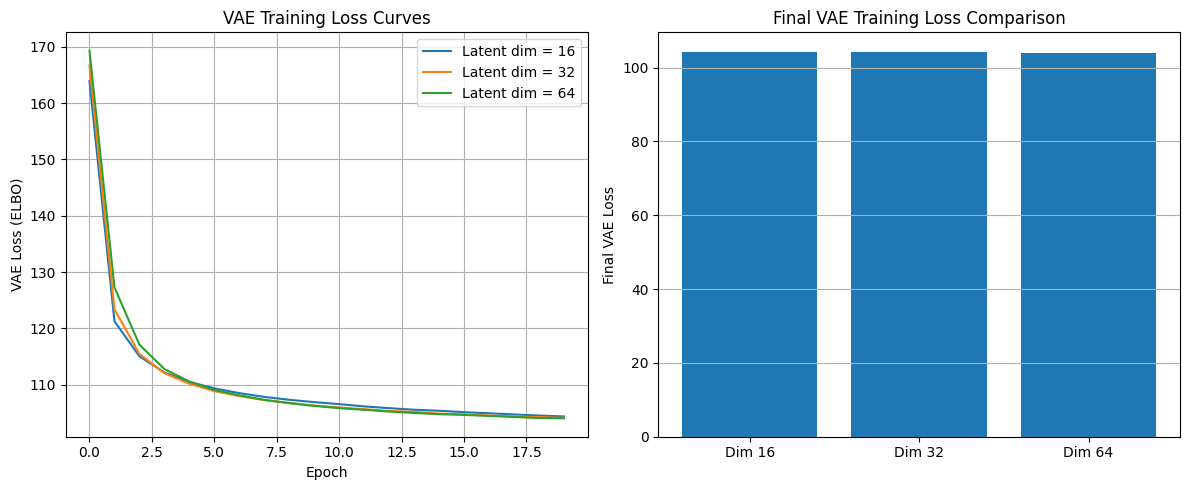


VAE Training Sample Reconstructions


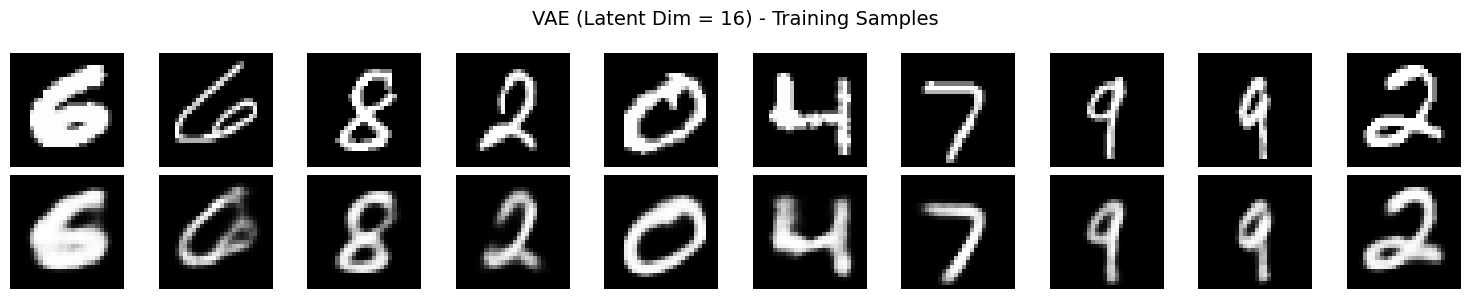

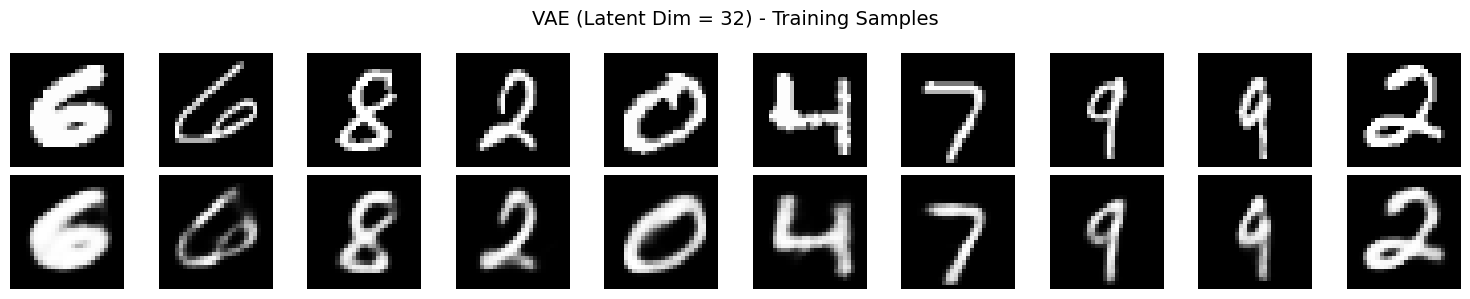

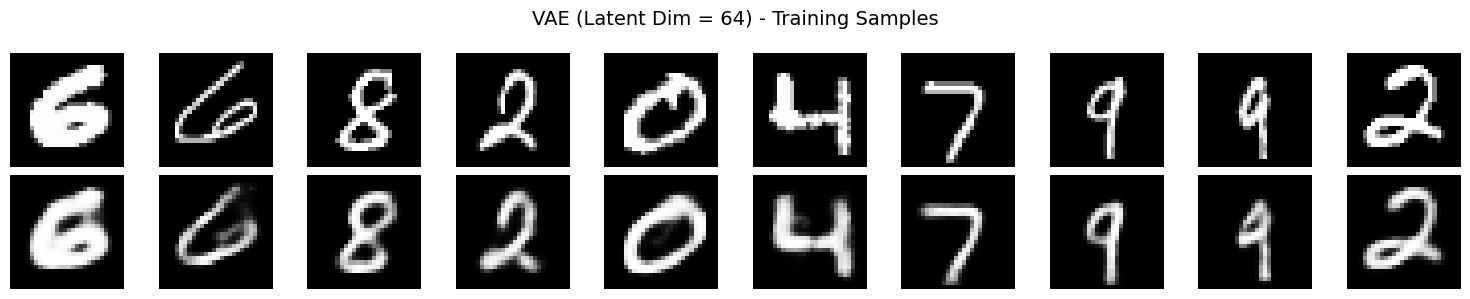


VAE Test Sample Reconstructions


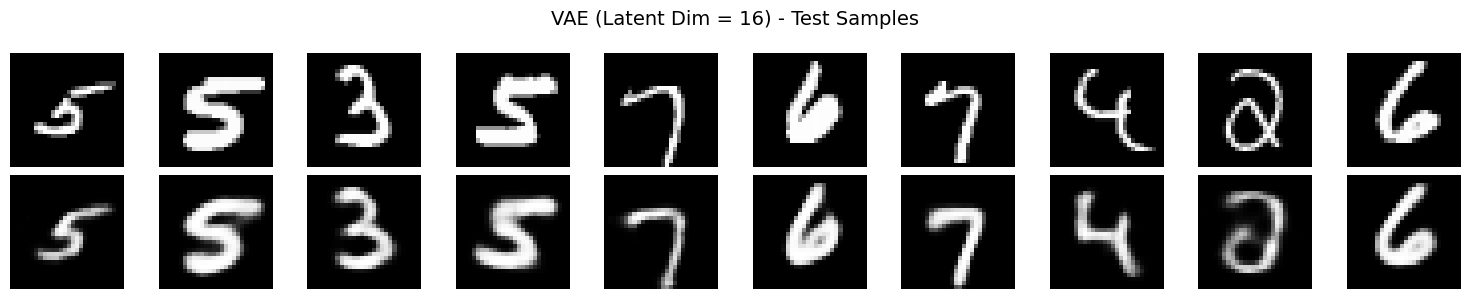

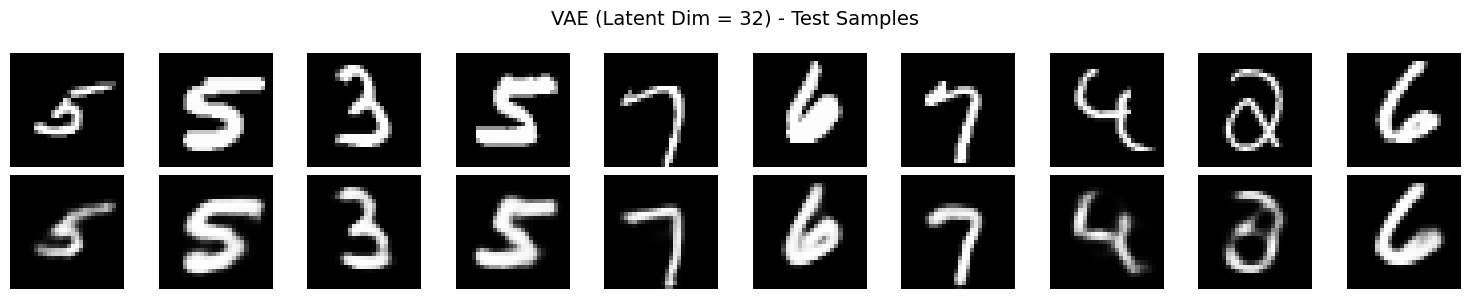

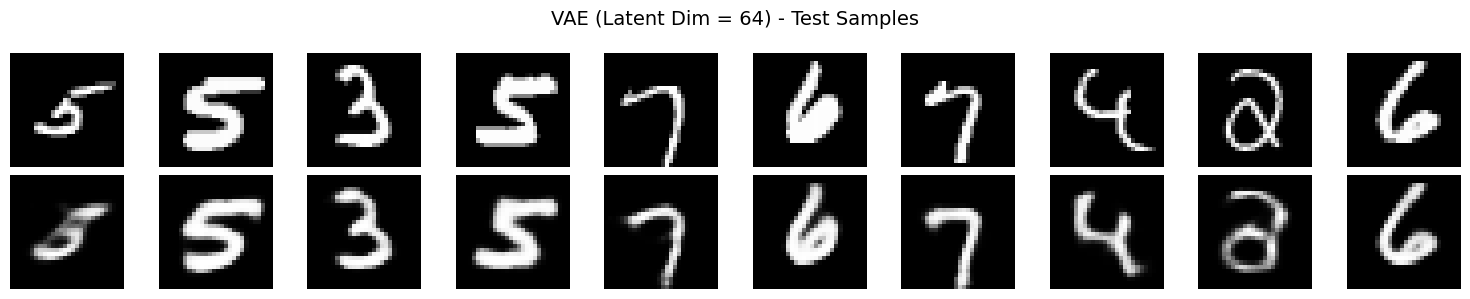


VAE Latent Space Sampling


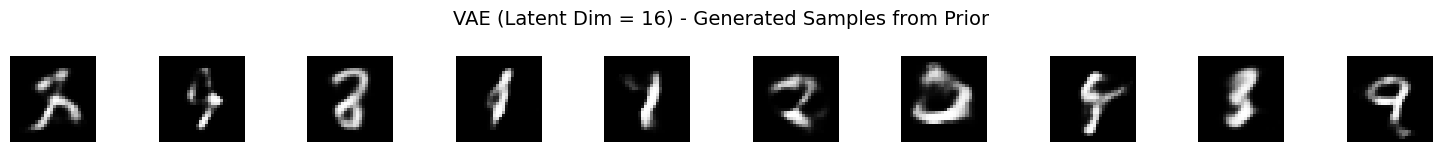

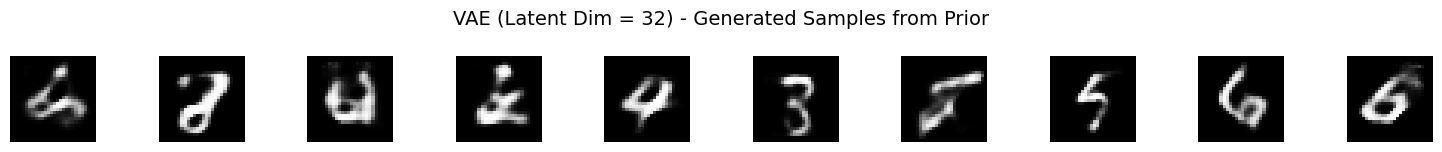

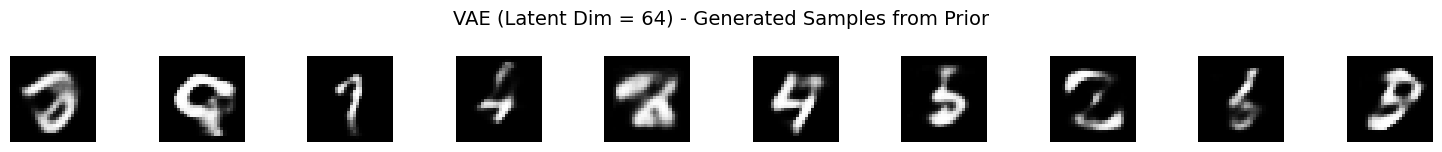


VAE Reconstruction Error Analysis

Latent Dimension: 16
  Training MSE: 0.013546
  Test MSE:     0.013637
  Difference:   0.000091

Latent Dimension: 32
  Training MSE: 0.012306
  Test MSE:     0.012376
  Difference:   0.000070

Latent Dimension: 64
  Training MSE: 0.012035
  Test MSE:     0.012121
  Difference:   0.000086

Discussion:

VAE Analysis:
1. Reconstruction Quality:
   - VAEs learn a probabilistic latent representation
   - The KL divergence term regularizes the latent space
   - Generally, higher latent dimensions improve reconstruction

2. Latent Space Structure:
   - VAEs learn a smooth, continuous latent space
   - The latent space follows a standard normal distribution (prior)
   - This enables generation of new samples by sampling from the prior

3. Trade-offs:
   - KL divergence regularizes the latent space but may reduce reconstruction quality
   - Higher latent dimensions allow more capacity but require more data
   - The balance between reconstruction and KL loss 

In [22]:
import torch  
import torch.optim as optim
import matplotlib.pyplot as plt # 
from VAE import VAE, vae_loss  #
import numpy as np # 


# Convert data to PyTorch tensors
x_train_tensor = torch.FloatTensor(x_train_flat)
x_test_tensor = torch.FloatTensor(x_test_flat)

print(f"Training data shape: {x_train_tensor.shape}")
print(f"Test data shape: {x_test_tensor.shape}")

# Training function for VAE
def train_vae(model, train_data, epochs=20, batch_size=128, lr=1e-3):
    """
    Train a VAE model
    
    Parameters:
        model: VAE model
        train_data: training data tensor
        epochs: number of epochs
        batch_size: batch size
        lr: learning rate
    
    Returns:
        losses: list of losses per epoch
    """
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    losses = []
    
    n_samples = train_data.shape[0]
    
    for epoch in range(epochs):
        epoch_loss = 0
        n_batches = 0
        
        # Shuffle data
        indices = torch.randperm(n_samples)
        
        for i in range(0, n_samples, batch_size):
            batch_indices = indices[i:i+batch_size]
            batch = train_data[batch_indices]
            
            # Forward pass
            x_hat, mu, logvar = model(batch)
            
            # Compute loss
            loss = vae_loss(batch, x_hat, mu, logvar)
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            n_batches += 1
        
        avg_loss = epoch_loss / n_batches
        losses.append(avg_loss)
        
        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch + 1}/{epochs}, Loss: {avg_loss:.6f}")
    
    return losses

# Train VAEs with different latent dimensions
vae_models = {}
vae_losses = {}
latent_dims_vae = [16, 32, 64]
hidden_dim = 400

for latent_dim in latent_dims_vae:
    print(f"\n{'='*60}")
    print(f"Training VAE with latent dimension: {latent_dim}")
    print(f"{'='*60}")
    
    # Initialize VAE
    vae = VAE(input_dim=784, hidden_dim=hidden_dim, latent_dim=latent_dim)
    
    # Train the VAE
    losses = train_vae(vae, x_train_tensor, epochs=20, batch_size=128, lr=1e-3)
    
    # Store model and losses
    vae_models[latent_dim] = vae
    vae_losses[latent_dim] = losses
    
    print(f"Final training loss: {losses[-1]:.6f}")

# Plot training loss curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for latent_dim in latent_dims_vae:
    plt.plot(vae_losses[latent_dim], label=f'Latent dim = {latent_dim}')
plt.xlabel('Epoch')
plt.ylabel('VAE Loss (ELBO)')
plt.title('VAE Training Loss Curves')
plt.legend()
plt.grid(True)

# Plot final losses comparison
plt.subplot(1, 2, 2)
final_losses_vae = [vae_losses[dim][-1] for dim in latent_dims_vae]
plt.bar(range(len(latent_dims_vae)), final_losses_vae)
plt.xticks(range(len(latent_dims_vae)), [f'Dim {d}' for d in latent_dims_vae])
plt.ylabel('Final VAE Loss')
plt.title('Final VAE Training Loss Comparison')
plt.grid(True, axis='y')

plt.tight_layout()
plt.show()

# Visualize reconstructions for training samples
print("\n" + "="*60)
print("VAE Training Sample Reconstructions")
print("="*60)

for latent_dim in latent_dims_vae:
    vae = vae_models[latent_dim]
    vae.eval()
    
    # Select 10 random training samples
    torch.manual_seed(42)
    train_indices = torch.randint(0, len(x_train_tensor), (10,))
    train_samples = x_train_tensor[train_indices]
    
    # Reconstruct
    with torch.no_grad():
        x_hat, _, _ = vae(train_samples)
    
    # Plot original and reconstructed images
    fig, axes = plt.subplots(2, 10, figsize=(15, 3))
    fig.suptitle(f'VAE (Latent Dim = {latent_dim}) - Training Samples', fontsize=14)
    
    for i in range(10):
        # Original
        axes[0, i].imshow(train_samples[i].numpy().reshape(28, 28), cmap='gray')
        axes[0, i].axis('off')
        if i == 0:
            axes[0, i].set_ylabel('Original', fontsize=10)
        
        # Reconstructed
        axes[1, i].imshow(x_hat[i].numpy().reshape(28, 28), cmap='gray')
        axes[1, i].axis('off')
        if i == 0:
            axes[1, i].set_ylabel('Reconstructed', fontsize=10)
    
    plt.tight_layout()
    plt.show()

# Visualize reconstructions for test samples
print("\n" + "="*60)
print("VAE Test Sample Reconstructions")
print("="*60)

for latent_dim in latent_dims_vae:
    vae = vae_models[latent_dim]
    vae.eval()
    
    # Select 10 random test samples
    torch.manual_seed(42)
    test_indices = torch.randint(0, len(x_test_tensor), (10,))
    test_samples = x_test_tensor[test_indices]
    
    # Reconstruct
    with torch.no_grad():
        x_hat, _, _ = vae(test_samples)
    
    # Plot original and reconstructed images
    fig, axes = plt.subplots(2, 10, figsize=(15, 3))
    fig.suptitle(f'VAE (Latent Dim = {latent_dim}) - Test Samples', fontsize=14)
    
    for i in range(10):
        # Original
        axes[0, i].imshow(test_samples[i].numpy().reshape(28, 28), cmap='gray')
        axes[0, i].axis('off')
        if i == 0:
            axes[0, i].set_ylabel('Original', fontsize=10)
        
        # Reconstructed
        axes[1, i].imshow(x_hat[i].numpy().reshape(28, 28), cmap='gray')
        axes[1, i].axis('off')
        if i == 0:
            axes[1, i].set_ylabel('Reconstructed', fontsize=10)
    
    plt.tight_layout()
    plt.show()

# Generate samples from latent space (VAE-specific capability)
print("\n" + "="*60)
print("VAE Latent Space Sampling")
print("="*60)

for latent_dim in latent_dims_vae:
    vae = vae_models[latent_dim]
    vae.eval()
    
    # Sample from prior distribution N(0, I)
    with torch.no_grad():
        z_sample = torch.randn(10, latent_dim)
        x_generated = vae.decode(z_sample)
    
    # Plot generated samples
    fig, axes = plt.subplots(1, 10, figsize=(15, 1.5))
    fig.suptitle(f'VAE (Latent Dim = {latent_dim}) - Generated Samples from Prior', fontsize=14)
    
    for i in range(10):
        axes[i].imshow(x_generated[i].numpy().reshape(28, 28), cmap='gray')
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

# Compute and compare reconstruction errors
print("\n" + "="*60)
print("VAE Reconstruction Error Analysis")
print("="*60)

for latent_dim in latent_dims_vae:
    vae = vae_models[latent_dim]
    vae.eval()
    
    # Training set reconstruction error
    with torch.no_grad():
        train_recon, _, _ = vae(x_train_tensor)
        train_mse = torch.mean((x_train_tensor - train_recon) ** 2).item()
    
    # Test set reconstruction error
    with torch.no_grad():
        test_recon, _, _ = vae(x_test_tensor)
        test_mse = torch.mean((x_test_tensor - test_recon) ** 2).item()
    
    print(f"\nLatent Dimension: {latent_dim}")
    print(f"  Training MSE: {train_mse:.6f}")
    print(f"  Test MSE:     {test_mse:.6f}")
    print(f"  Difference:   {abs(train_mse - test_mse):.6f}")

print("\n" + "="*60)
print("Discussion:")
print("="*60)
print("""
VAE Analysis:
1. Reconstruction Quality:
   - VAEs learn a probabilistic latent representation
   - The KL divergence term regularizes the latent space
   - Generally, higher latent dimensions improve reconstruction

2. Latent Space Structure:
   - VAEs learn a smooth, continuous latent space
   - The latent space follows a standard normal distribution (prior)
   - This enables generation of new samples by sampling from the prior

3. Trade-offs:
   - KL divergence regularizes the latent space but may reduce reconstruction quality
   - Higher latent dimensions allow more capacity but require more data
   - The balance between reconstruction and KL loss is important

4. Generation Capability:
   - VAEs can generate new samples by sampling from the prior distribution
   - This is a key advantage over standard autoencoders
   - The generated samples should follow the learned data distribution
""")

## Comparison of Standard Autoencoders and Variational Autoencoders

Once you have implemented both the standard autoencoder and the variational autoencoder, you can analyze and compare them along:

**Reconstruction Quality**  
   - Compare reconstructed images from both models on 10 sample training image and 10 sample test image.  
   - Note how accurately each model preserves details of the input images.

Comparison: Standard Autoencoder vs Variational Autoencoder

Training Samples Comparison (Latent Dim = 32)


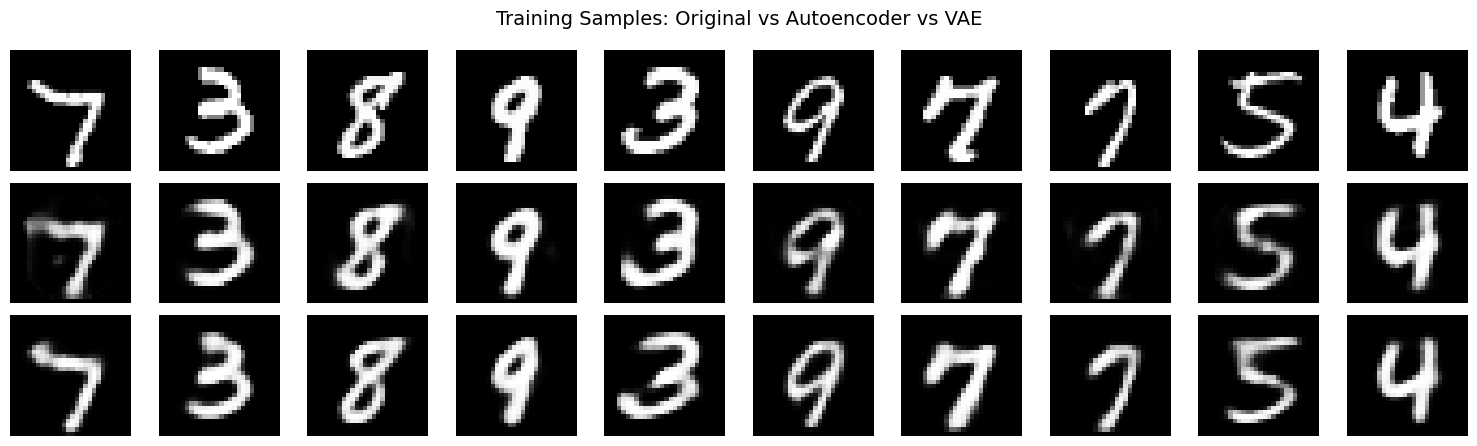


Test Samples Comparison (Latent Dim = 32)


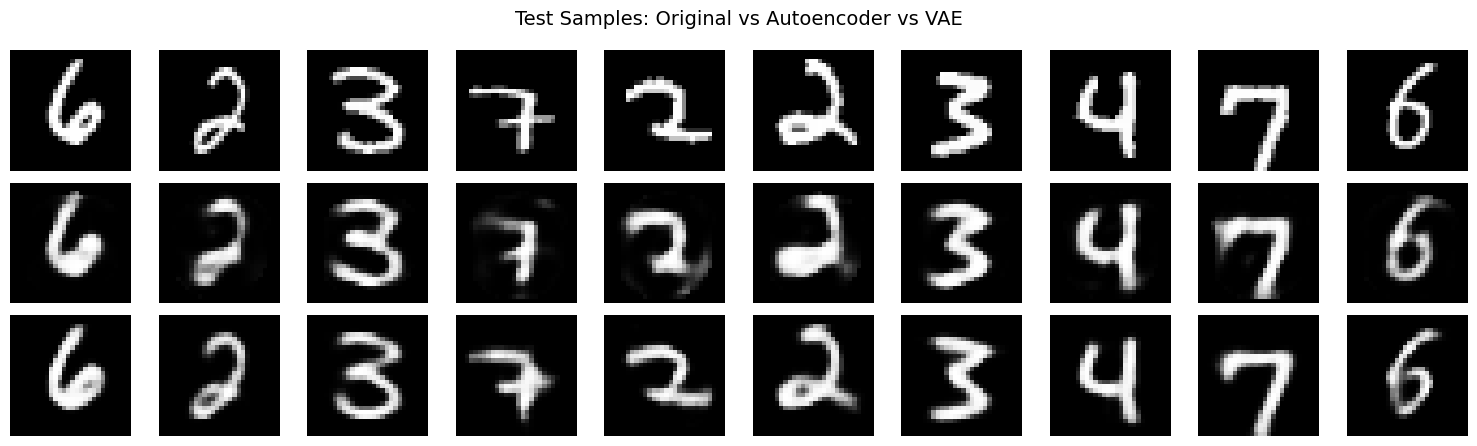


Quantitative Comparison (Latent Dim = 32)

Training Samples:
  Autoencoder MSE: 0.009267
  VAE MSE:         0.011048
  Difference:      0.001781

Test Samples:
  Autoencoder MSE: 0.011859
  VAE MSE:         0.012264
  Difference:      0.000405

Full Dataset Comparison (Latent Dim = 32)

Training Set (sample of 1000):
  Autoencoder MSE: 0.011775
  VAE MSE:         0.012516

Test Set (sample of 1000):
  Autoencoder MSE: 0.011432
  VAE MSE:         0.012586


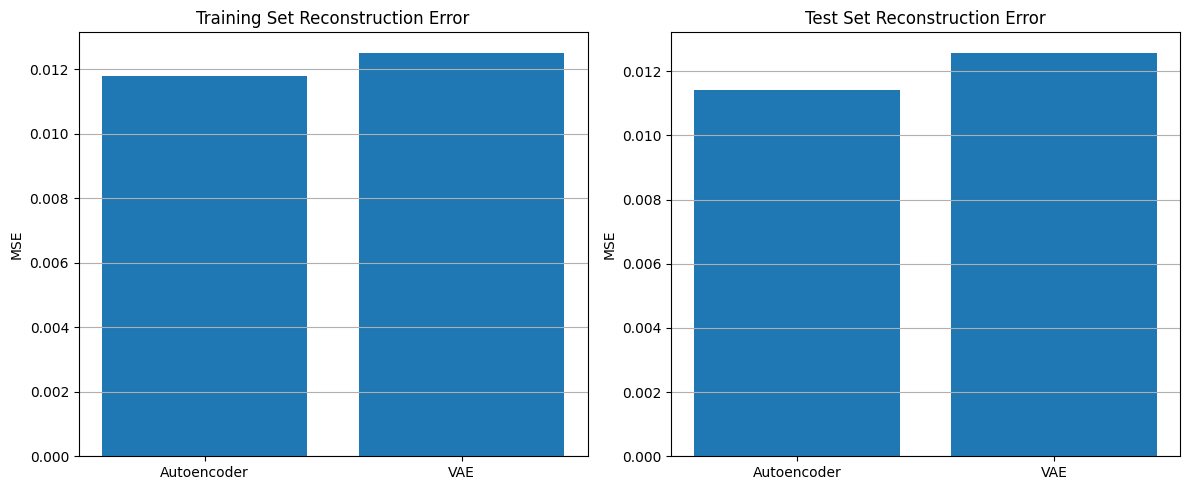


Summary and Discussion:

Key Differences between Standard Autoencoder and VAE:

1. **Latent Space Representation:**
   - Standard AE: Deterministic mapping to latent codes
   - VAE: Probabilistic mapping to latent distributions (mean and variance)

2. **Reconstruction Quality:**
   - Standard AE: May achieve lower reconstruction error due to deterministic encoding
   - VAE: Slightly higher reconstruction error due to KL regularization, but smoother latent space

3. **Regularization:**
   - Standard AE: Regularized only by bottleneck size
   - VAE: Additional KL divergence regularization encourages smooth, continuous latent space

4. **Generation Capability:**
   - Standard AE: Cannot generate new samples directly
   - VAE: Can generate new samples by sampling from prior distribution N(0, I)

5. **Interpolation:**
   - Standard AE: Interpolation may not be smooth
   - VAE: Interpolation is typically smoother due to regularized latent space

6. **Use Cases:**
   - Standard AE: Better fo

In [23]:
# Comparison between Standard Autoencoder and VAE
print("="*60)
print("Comparison: Standard Autoencoder vs Variational Autoencoder")
print("="*60)

# Use latent dimension 32 for fair comparison
latent_dim_compare = 32
ae_compare = autoencoders[latent_dim_compare]
vae_compare = vae_models[latent_dim_compare]
vae_compare.eval()

# Select 10 random training samples
np.random.seed(42)
train_indices_compare = np.random.choice(len(x_train_flat), 10, replace=False)
train_samples_compare = x_train_flat[train_indices_compare]
train_samples_compare_tensor = torch.FloatTensor(train_samples_compare)

# Select 10 random test samples
np.random.seed(42)
test_indices_compare = np.random.choice(len(x_test_flat), 10, replace=False)
test_samples_compare = x_test_flat[test_indices_compare]
test_samples_compare_tensor = torch.FloatTensor(test_samples_compare)

# Reconstruct using Autoencoder
ae_train_recon = ae_compare.reconstruct(train_samples_compare)
ae_test_recon = ae_compare.reconstruct(test_samples_compare)

# Reconstruct using VAE
with torch.no_grad():
    vae_train_recon, _, _ = vae_compare(train_samples_compare_tensor)
    vae_test_recon, _, _ = vae_compare(test_samples_compare_tensor)
vae_train_recon = vae_train_recon.numpy()
vae_test_recon = vae_test_recon.numpy()

# Visualize training samples comparison
print("\nTraining Samples Comparison (Latent Dim = 32)")
fig, axes = plt.subplots(3, 10, figsize=(15, 4.5))
fig.suptitle('Training Samples: Original vs Autoencoder vs VAE', fontsize=14)

for i in range(10):
    # Original
    axes[0, i].imshow(train_samples_compare[i].reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_ylabel('Original', fontsize=10)
    
    # Autoencoder reconstruction
    axes[1, i].imshow(ae_train_recon[i].reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_ylabel('Autoencoder', fontsize=10)
    
    # VAE reconstruction
    axes[2, i].imshow(vae_train_recon[i].reshape(28, 28), cmap='gray')
    axes[2, i].axis('off')
    if i == 0:
        axes[2, i].set_ylabel('VAE', fontsize=10)

plt.tight_layout()
plt.show()

# Visualize test samples comparison
print("\nTest Samples Comparison (Latent Dim = 32)")
fig, axes = plt.subplots(3, 10, figsize=(15, 4.5))
fig.suptitle('Test Samples: Original vs Autoencoder vs VAE', fontsize=14)

for i in range(10):
    # Original
    axes[0, i].imshow(test_samples_compare[i].reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_ylabel('Original', fontsize=10)
    
    # Autoencoder reconstruction
    axes[1, i].imshow(ae_test_recon[i].reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_ylabel('Autoencoder', fontsize=10)
    
    # VAE reconstruction
    axes[2, i].imshow(vae_test_recon[i].reshape(28, 28), cmap='gray')
    axes[2, i].axis('off')
    if i == 0:
        axes[2, i].set_ylabel('VAE', fontsize=10)

plt.tight_layout()
plt.show()

# Quantitative comparison
print("\n" + "="*60)
print("Quantitative Comparison (Latent Dim = 32)")
print("="*60)

# Compute MSE for training samples
ae_train_mse = np.mean((train_samples_compare - ae_train_recon) ** 2)
vae_train_mse = np.mean((train_samples_compare - vae_train_recon) ** 2)

# Compute MSE for test samples
ae_test_mse = np.mean((test_samples_compare - ae_test_recon) ** 2)
vae_test_mse = np.mean((test_samples_compare - vae_test_recon) ** 2)

print(f"\nTraining Samples:")
print(f"  Autoencoder MSE: {ae_train_mse:.6f}")
print(f"  VAE MSE:         {vae_train_mse:.6f}")
print(f"  Difference:      {abs(ae_train_mse - vae_train_mse):.6f}")

print(f"\nTest Samples:")
print(f"  Autoencoder MSE: {ae_test_mse:.6f}")
print(f"  VAE MSE:         {vae_test_mse:.6f}")
print(f"  Difference:      {abs(ae_test_mse - vae_test_mse):.6f}")

# Compare full dataset reconstruction errors
print("\n" + "="*60)
print("Full Dataset Comparison (Latent Dim = 32)")
print("="*60)

# Sample a subset for faster computation
sample_size = 1000
train_sample_indices = np.random.choice(len(x_train_flat), sample_size, replace=False)
test_sample_indices = np.random.choice(len(x_test_flat), sample_size, replace=False)

train_sample = x_train_flat[train_sample_indices]
test_sample = x_test_flat[test_sample_indices]

# Autoencoder
ae_train_full_recon = ae_compare.reconstruct(train_sample)
ae_test_full_recon = ae_compare.reconstruct(test_sample)
ae_train_full_mse = np.mean((train_sample - ae_train_full_recon) ** 2)
ae_test_full_mse = np.mean((test_sample - ae_test_full_recon) ** 2)

# VAE
with torch.no_grad():
    train_sample_tensor = torch.FloatTensor(train_sample)
    test_sample_tensor = torch.FloatTensor(test_sample)
    vae_train_full_recon, _, _ = vae_compare(train_sample_tensor)
    vae_test_full_recon, _, _ = vae_compare(test_sample_tensor)
vae_train_full_mse = np.mean((train_sample - vae_train_full_recon.numpy()) ** 2)
vae_test_full_mse = np.mean((test_sample - vae_test_full_recon.numpy()) ** 2)

print(f"\nTraining Set (sample of {sample_size}):")
print(f"  Autoencoder MSE: {ae_train_full_mse:.6f}")
print(f"  VAE MSE:         {vae_train_full_mse:.6f}")

print(f"\nTest Set (sample of {sample_size}):")
print(f"  Autoencoder MSE: {ae_test_full_mse:.6f}")
print(f"  VAE MSE:         {vae_test_full_mse:.6f}")

# Plot comparison of MSE
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Training set comparison
axes[0].bar(['Autoencoder', 'VAE'], [ae_train_full_mse, vae_train_full_mse])
axes[0].set_ylabel('MSE')
axes[0].set_title('Training Set Reconstruction Error')
axes[0].grid(True, axis='y')

# Test set comparison
axes[1].bar(['Autoencoder', 'VAE'], [ae_test_full_mse, vae_test_full_mse])
axes[1].set_ylabel('MSE')
axes[1].set_title('Test Set Reconstruction Error')
axes[1].grid(True, axis='y')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("Summary and Discussion:")
print("="*60)
print("""
Key Differences between Standard Autoencoder and VAE:

1. **Latent Space Representation:**
   - Standard AE: Deterministic mapping to latent codes
   - VAE: Probabilistic mapping to latent distributions (mean and variance)

2. **Reconstruction Quality:**
   - Standard AE: May achieve lower reconstruction error due to deterministic encoding
   - VAE: Slightly higher reconstruction error due to KL regularization, but smoother latent space

3. **Regularization:**
   - Standard AE: Regularized only by bottleneck size
   - VAE: Additional KL divergence regularization encourages smooth, continuous latent space

4. **Generation Capability:**
   - Standard AE: Cannot generate new samples directly
   - VAE: Can generate new samples by sampling from prior distribution N(0, I)

5. **Interpolation:**
   - Standard AE: Interpolation may not be smooth
   - VAE: Interpolation is typically smoother due to regularized latent space

6. **Use Cases:**
   - Standard AE: Better for compression, denoising, dimensionality reduction
   - VAE: Better for generative modeling, representation learning with smooth latent space

7. **Trade-offs:**
   - Standard AE: Simpler, faster, better reconstruction but limited generative capability
   - VAE: More complex, slightly worse reconstruction but enables generation and smoother representations
""")


Important: Please read the questions and #TODOs carefully to implement all the steps to complete the assignment. You may add or subtract methods to the python scripts according to your needs. Feel free to e-mail ergunesr@itu.edu.tr for your questions.  